In [1]:
# ============================================================
# CELL 1 — Environment setup & sys.path
# ============================================================

import sys
import os

parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

np_seed = 42 

In [2]:
# ============================================================
# CELL 2 — All imports (consolidated, no duplicates)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.datasets import fetch_california_housing, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression as SklearnLR

from src.linear_regression import LinearRegression as CustomLR
from src.linear_regression_gd import LinearRegressionGD

In [3]:
# ============================================================
# CELL 3 — Load California Housing dataset
# ============================================================

california = fetch_california_housing(as_frame=True)

X = california['data'][['MedInc']]
y = california['target']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature (X) preview:")
print(X.head())
print("\nTarget (y) preview:")
print(y.head())


X shape: (20640, 1)
y shape: (20640,)

Feature (X) preview:
   MedInc
0  8.3252
1  8.3014
2  7.2574
3  5.6431
4  3.8462

Target (y) preview:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [4]:
# ============================================================
# CELL 4 — Train / validation split  (Part 4.1.3)
# ============================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    train_size=100,
    test_size=100,
    random_state=42
)

x_train_arr = X_train["MedInc"].values
x_val_arr   = X_val["MedInc"].values
y_train_arr = y_train.values
y_val_arr   = y_val.values

In [5]:
# ============================================================
# CELL 5 — Part 4.1.1: OLS sanity check
# ============================================================
print("--- Running Sanity Check for OLS ---")

np.random.seed(42)
X_random = np.random.rand(100, 5)
y_random = (3 * X_random[:, 0]
            + 1.5 * X_random[:, 2]
            - 2 * X_random[:, 4]
            + np.random.randn(100) * 0.1)

sk_model = SklearnLR(fit_intercept=True)
sk_model.fit(X_random, y_random)
sk_preds = sk_model.predict(X_random)

my_model = CustomLR()
my_model.fit(X_random, y_random)
my_preds = my_model.predict(X_random)

is_match = np.allclose(sk_preds, my_preds, atol=1e-9)
print(f"Outputs match within 10^-9: {is_match}")
if is_match:
    print("Sanity check passed! Custom OLS is mathematically identical to sklearn.")
else:
    print("Sanity check failed. Check your matrix inversion math in src!")

--- Running Sanity Check for OLS ---
Outputs match within 10^-9: True
Sanity check passed! Custom OLS is mathematically identical to sklearn.


Learning Rate 0.001 converged in 1000 iterations.
Learning Rate 0.01 converged in 823 iterations.
Learning Rate 0.1 converged in 90 iterations.


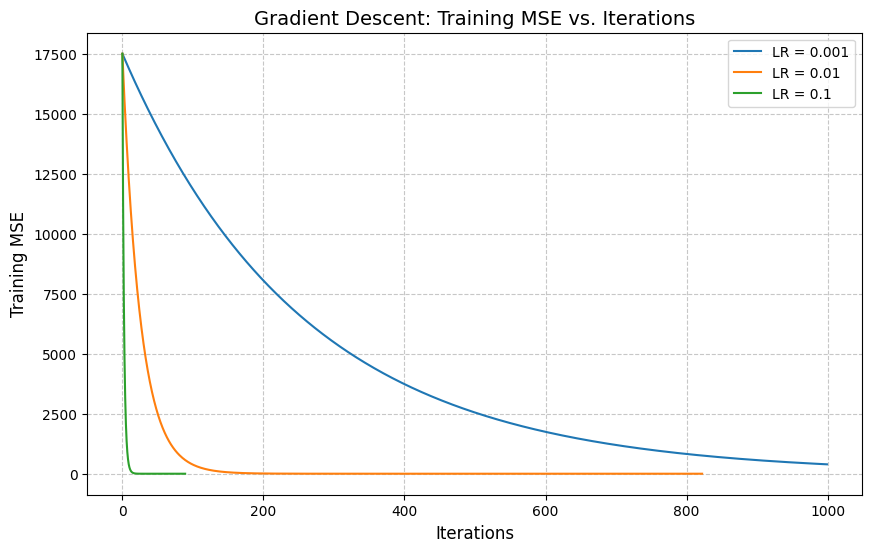

In [7]:
# ============================================================
# CELL 6 — Part 4.1.2: Gradient descent experiments
# ============================================================
X_syn, y_syn = make_regression(n_samples=1000, n_features=10, noise=0.5, random_state=42)

learning_rates = [0.001, 0.01, 0.1]
gd_models = {}

plt.figure(figsize=(10, 6))

for current_lr in learning_rates:
    model_gd = LinearRegressionGD(lr=current_lr)
    model_gd.fit(X_syn, y_syn)
    gd_models[current_lr] = model_gd
    plt.plot(model_gd.loss_history, label=f'LR = {current_lr}')
    print(f"Learning Rate {current_lr} converged in {len(model_gd.loss_history)} iterations.")

plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Training MSE', fontsize=12)
plt.title('Gradient Descent: Training MSE vs. Iterations', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('../figures/Gradient_Descent_Training_MSE_Iterations.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# CELL 7 — Part 4.1.2: Compare GD weights with OLS weights
# ============================================================
print("\n--- Weight Comparison (GD vs OLS) ---")

ols_model = CustomLR()
ols_model.fit(X_syn, y_syn)

best_gd_model = gd_models[0.1]
weights_match = np.allclose(best_gd_model.w_weights, ols_model.weights, atol=1e-4)

print(f"Do the GD weights (LR=0.1) match OLS weights within 10^-4? {weights_match}")
if weights_match:
    print("Success! Gradient Descent converged to the exact same global minimum as OLS.")
else:
    print("Failed: Weights did not match perfectly. Double check your gradient math!")


--- Weight Comparison (GD vs OLS) ---
Do the GD weights (LR=0.1) match OLS weights within 10^-4? True
Success! Gradient Descent converged to the exact same global minimum as OLS.


In [9]:
# ============================================================
# CELL 8 — Part 4.1.3: Polynomial fitting & overfitting
# ============================================================
train_mse_list = []
val_mse_list   = []
degrees = range(1, 13)

for d in degrees:
    X_train_poly = np.column_stack([x_train_arr**i for i in range(1, d + 1)])
    X_val_poly   = np.column_stack([x_val_arr**i   for i in range(1, d + 1)])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_val_scaled   = scaler.transform(X_val_poly)

    model = CustomLR()
    model.fit(X_train_scaled, y_train_arr)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred   = model.predict(X_val_scaled)

    train_mse_list.append(mean_squared_error(y_train_arr, y_train_pred))
    val_mse_list.append(mean_squared_error(y_val_arr,   y_val_pred))

print("Experiment loop complete! MSE values successfully stored.")
print(train_mse_list)
print(val_mse_list)

Experiment loop complete! MSE values successfully stored.
[0.6425542440376449, 0.6125081664317754, 0.6121250577105978, 0.5993466756469221, 0.5967329316683178, 0.5863296326782069, 0.5757119029711455, 0.5514246816048096, 0.550803058052713, 0.5508270855498862, 0.5647657208146523, 0.5494528522528216]
[0.76629584692194, 0.7624425654751512, 0.7663375653691108, 0.7572854560146318, 0.7629947414996409, 0.7768353127789591, 0.7543216507684021, 0.745659663509728, 0.7500442782783024, 0.7502926920582169, 0.7511638408416182, 0.7495711396406008]


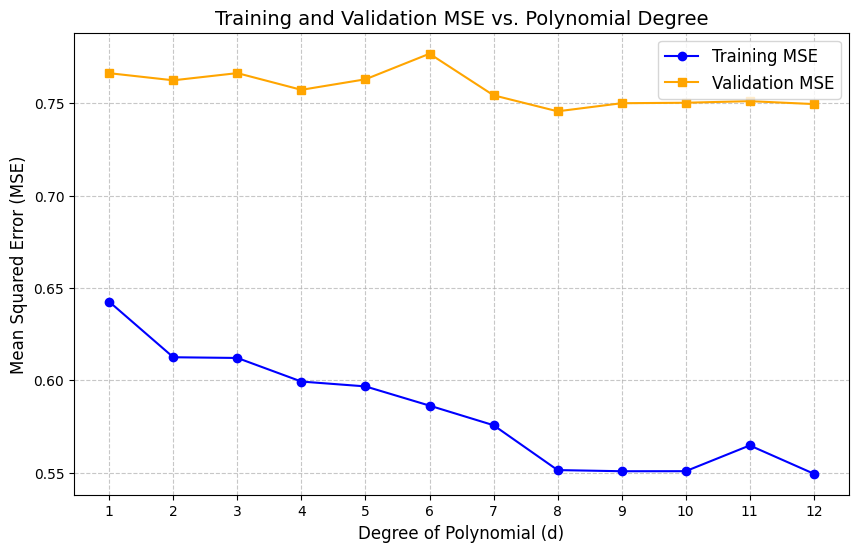

--- Results ---
The degree with the lowest validation MSE is: d = 8
The lowest validation MSE achieved is: 0.7457


In [10]:
# ============================================================
# CELL 9 — Part 4.1.3: Plot Training vs Validation MSE
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mse_list, label='Training MSE',   marker='o', color='blue')
plt.plot(degrees, val_mse_list,   label='Validation MSE', marker='s', color='orange')
plt.xlabel('Degree of Polynomial (d)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Training and Validation MSE vs. Polynomial Degree', fontsize=14)
plt.xticks(degrees)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('../figures/Training and Validation MSE vs. Polynomial Degree.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

best_index    = np.argmin(val_mse_list)
best_d        = list(degrees)[best_index]
lowest_val_mse = val_mse_list[best_index]
print(f"--- Results ---")
print(f"The degree with the lowest validation MSE is: d = {best_d}")
print(f"The lowest validation MSE achieved is: {lowest_val_mse:.4f}")

In [12]:
# ============================================================
# CELL 10 — Part 4.1.5: Prediction intervals (d=5)
# ============================================================
d = 5

X_train_poly = np.column_stack([x_train_arr**i for i in range(1, d + 1)])
X_val_poly   = np.column_stack([x_val_arr**i   for i in range(1, d + 1)])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled   = scaler.transform(X_val_poly)

model_d5 = CustomLR()
model_d5.fit(X_train_scaled, y_train_arr)

X_train_design = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
X_val_design   = np.column_stack([np.ones(len(X_val_scaled)),   X_val_scaled])

N = X_train_design.shape[0]
p = X_train_design.shape[1]

y_train_pred  = model_d5.predict(X_train_scaled)
sigma_squared = (1 / (N - p)) * np.sum((y_train_arr - y_train_pred)**2)

XTX_inv = np.linalg.inv(X_train_design.T @ X_train_design)
t_val   = stats.t.ppf(0.975, df=N - p)

lower_bounds = []
upper_bounds = []
y_val_pred = model_d5.predict(X_val_scaled)

for i in range(len(X_val_design)):
    x_star         = X_val_design[i]
    leverage       = x_star.T @ XTX_inv @ x_star
    margin_of_error = t_val * np.sqrt(sigma_squared * (1 + leverage))
    prediction     = y_val_pred[i]
    lower_bounds.append(prediction - margin_of_error)
    upper_bounds.append(prediction + margin_of_error)

print("d=5 prediction bounds calculated successfully!")

d=5 prediction bounds calculated successfully!


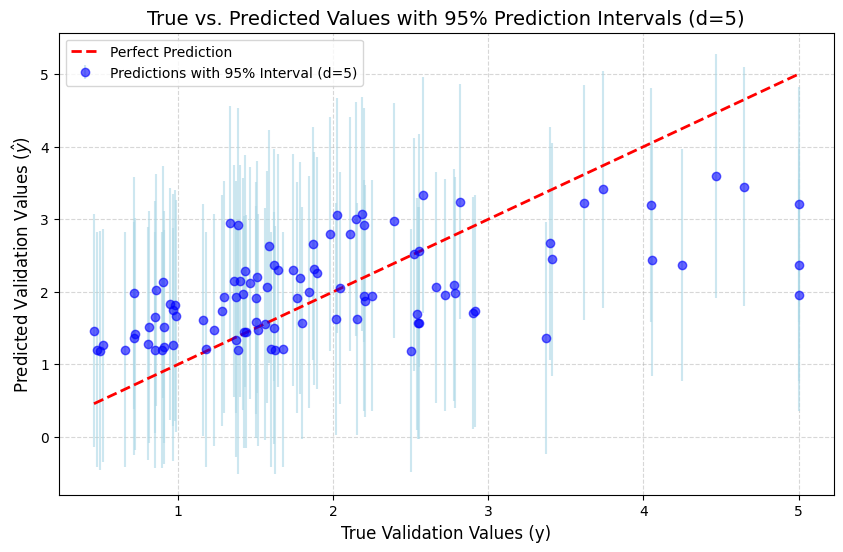

In [13]:
# ============================================================
# CELL 11 — Part 4.1.5: Plot prediction intervals (d=5)
# ============================================================
y_val_pred   = np.array(y_val_pred)
upper_bounds = np.array(upper_bounds)
error_bars   = upper_bounds - y_val_pred

plt.figure(figsize=(10, 6))
plt.errorbar(
    y_val_arr, y_val_pred,
    yerr=error_bars,
    fmt='o',
    color='blue',
    ecolor='lightblue',
    alpha=0.6,
    label='Predictions with 95% Interval (d=5)'
)

min_val = np.min(y_val_arr)
max_val = np.max(y_val_arr)
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel('True Validation Values (y)', fontsize=12)
plt.ylabel(r'Predicted Validation Values ($\hat{y}$)', fontsize=12)
plt.title('True vs. Predicted Values with 95% Prediction Intervals (d=5)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('../figures/True vs. Predicted Values with 95% Prediction Intervals (d=5).pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
import numpy as np
from sklearn.linear_model import Ridge
from numpy.testing import assert_allclose
from src.ridge_regression import RidgeRegression

# 1. Generate synthetic data for testing
np.random.seed(42)
X_verify = np.random.rand(100, 5) # 100 samples, 5 features
y_verify = np.random.rand(100)    # 100 target values
lambda_val = 1.0

# 2. Fit your custom Ridge model
custom_ridge = RidgeRegression(lambda_=lambda_val)
custom_ridge.fit(X_verify, y_verify)
custom_preds = custom_ridge.predict(X_verify)

# 3. Fit the scikit-learn Ridge model
# In scikit-learn, the regularization parameter lambda is named 'alpha'.
# We set fit_intercept=True because your custom model appends a column of 1s.
sklearn_ridge = Ridge(alpha=lambda_val, fit_intercept=True)
sklearn_ridge.fit(X_verify, y_verify)
sklearn_preds = sklearn_ridge.predict(X_verify)

# 4. Verification Tests
try:
    # Test 1: Compare predictions
    assert_allclose(custom_preds, sklearn_preds, rtol=1e-9, atol=1e-9)
    print("SUCCESS: Predictions match scikit-learn within 10^-9 tolerance!")
    
    # Test 2: Compare learned weights
    # sklearn stores features weights in .coef_ and the bias in .intercept_
    # Your model stores them together, with the bias at the very end.
    sklearn_weights_combined = np.append(sklearn_ridge.coef_, sklearn_ridge.intercept_)
    
    assert_allclose(custom_ridge.weights, sklearn_weights_combined, rtol=1e-9, atol=1e-9)
    print("SUCCESS: Weights and Intercept match scikit-learn within 10^-9 tolerance!")

except AssertionError as e:
    print("FAILURE: Models do not match within tolerance.")
    print(e)

SUCCESS: Predictions match scikit-learn within 10^-9 tolerance!
SUCCESS: Weights and Intercept match scikit-learn within 10^-9 tolerance!


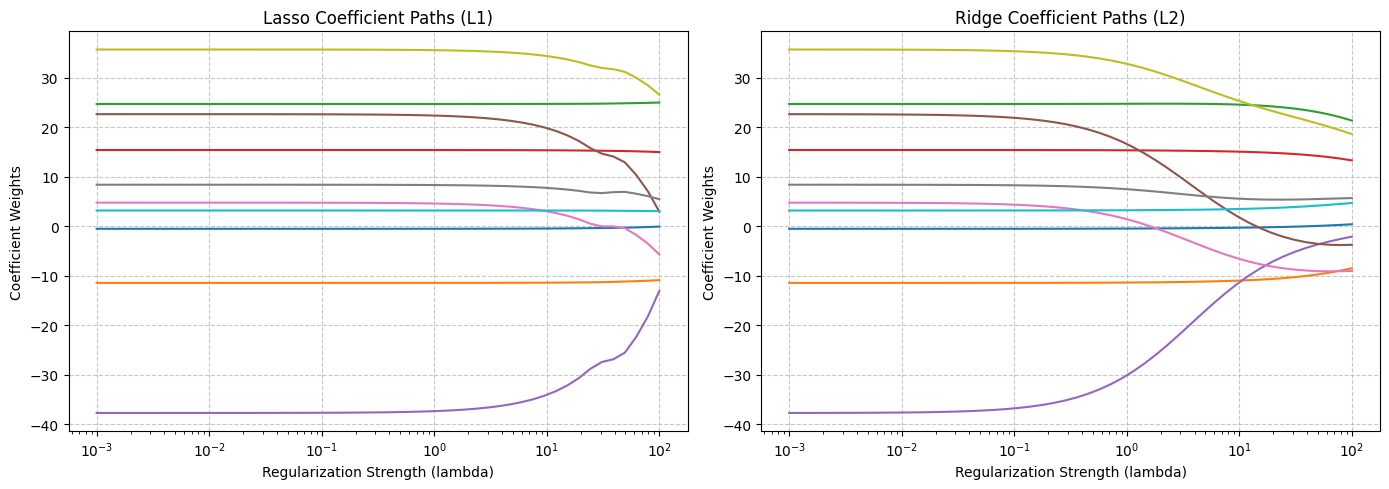

In [15]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from src.lasso_regression import LassoRegression

# 1. Load and Standardize the Diabetes Dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

# It is standard practice to standardize X and center y for regularization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_centered = y - np.mean(y)

# 2. Define lambda range: logarithmically spaced between 10^-3 and 10^2
# Using 50 points provides a smooth line for the plot
lambdas = np.logspace(-3, 2, 50)

# 3. Fit models and store weights
lasso_weights = []
ridge_weights = []

for lam in lambdas:
    # Fit Lasso
    lasso_model = LassoRegression(lambda_=lam, max_iter=10000, tol=1e-4)
    lasso_model.fit(X_scaled, y_centered)
    lasso_weights.append(lasso_model.weights.copy())
    
    # Fit Ridge
    ridge_model = RidgeRegression(lambda_=lam)
    ridge_model.fit(X_scaled, y_centered)
    # Note: Your Ridge implementation puts the bias term at the very end of the weights array.
    # We slice with [:-1] to extract only the feature weights for plotting.
    ridge_weights.append(ridge_model.weights[:-1].copy())

lasso_weights = np.array(lasso_weights)
ridge_weights = np.array(ridge_weights)

# 4. Plot the coefficient paths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Lasso Plot
ax1.plot(lambdas, lasso_weights)
ax1.set_xscale('log') # Logarithmic scale for the x-axis
ax1.set_xlabel('Regularization Strength (lambda)')
ax1.set_ylabel('Coefficient Weights')
ax1.set_title('Lasso Coefficient Paths (L1)')
ax1.grid(True, linestyle='--', alpha=0.7)

# Panel 2: Ridge Plot
ax2.plot(lambdas, ridge_weights)
ax2.set_xscale('log') # Logarithmic scale for the x-axis
ax2.set_xlabel('Regularization Strength (lambda)')
ax2.set_ylabel('Coefficient Weights')
ax2.set_title('Ridge Coefficient Paths (L2)')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(
    '../figures/Lasso_Coefficient_Paths_(L1)_and_Ridge_Coefficient_Paths_(L2).pdf',
    format='pdf', 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()


Grid Search Time: 0.3499 seconds | Best Lambda: 29.7635 | Best RMSE: 0.7282
Random Search Time: 0.4062 seconds | Best Lambda: 46.1935 | Best RMSE: 0.7281


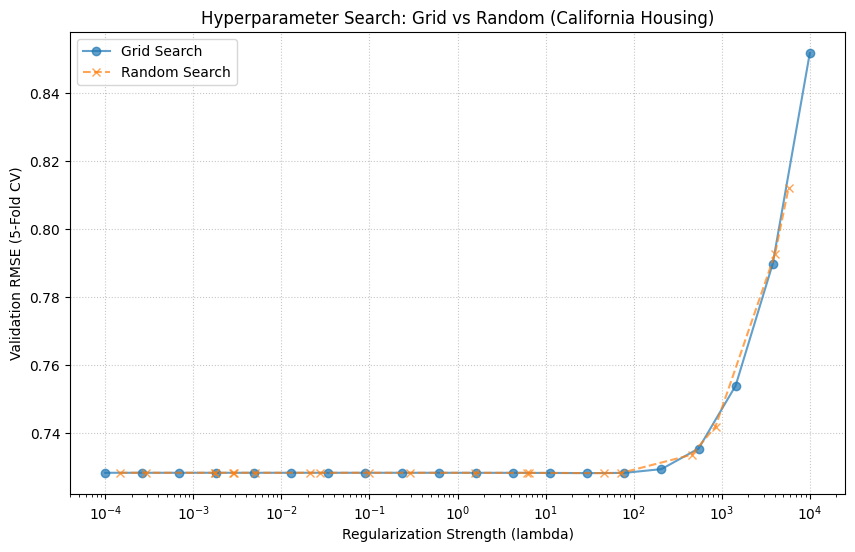

In [16]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# 1. Load and standardize the California Housing dataset
california = fetch_california_housing()
X, y = california.data, california.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# We don't need to strictly center y because your RidgeRegression inherently adds an intercept

# 2. Define lambda values
np.random.seed(42) # For reproducibility
grid_lambdas = np.logspace(-4, 4, 20)
random_lambdas = 10 ** np.random.uniform(-4, 4, 20)

# Sort random_lambdas strictly for cleaner plotting later
random_lambdas = np.sort(random_lambdas)

# 3. Setup 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_search_strategy(lambdas, X_data, y_data):
    rmse_scores = []
    
    for lam in lambdas:
        fold_rmses = []
        for train_idx, val_idx in kf.split(X_data):
            X_tr, X_val = X_data[train_idx], X_data[val_idx]
            y_tr, y_val = y_data[train_idx], y_data[val_idx]
            
            model = RidgeRegression(lambda_=lam)
            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)
            
            rmse = np.sqrt(mean_squared_error(y_val, preds))
            fold_rmses.append(rmse)
            
        rmse_scores.append(np.mean(fold_rmses))
    return np.array(rmse_scores)

# --- Evaluate Grid Search ---
start_time = time.time()
grid_rmses = evaluate_search_strategy(grid_lambdas, X_scaled, y)
grid_time = time.time() - start_time

best_grid_idx = np.argmin(grid_rmses)
best_grid_lam = grid_lambdas[best_grid_idx]

# --- Evaluate Random Search ---
start_time = time.time()
random_rmses = evaluate_search_strategy(random_lambdas, X_scaled, y)
random_time = time.time() - start_time

best_random_idx = np.argmin(random_rmses)
best_random_lam = random_lambdas[best_random_idx]

# 4. Reporting
print(f"Grid Search Time: {grid_time:.4f} seconds | Best Lambda: {best_grid_lam:.4f} | Best RMSE: {grid_rmses[best_grid_idx]:.4f}")
print(f"Random Search Time: {random_time:.4f} seconds | Best Lambda: {best_random_lam:.4f} | Best RMSE: {random_rmses[best_random_idx]:.4f}")

# 5. Plotting
plt.figure(figsize=(10, 6))
plt.plot(grid_lambdas, grid_rmses, marker='o', label='Grid Search', linestyle='-', alpha=0.7)
plt.plot(random_lambdas, random_rmses, marker='x', label='Random Search', linestyle='--', alpha=0.7)
plt.xscale('log')
plt.xlabel('Regularization Strength (lambda)')
plt.ylabel('Validation RMSE (5-Fold CV)')
plt.title('Hyperparameter Search: Grid vs Random (California Housing)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('../figures/Hyperparameter_Search_Grid_vs_Random_(California_Housing).pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()


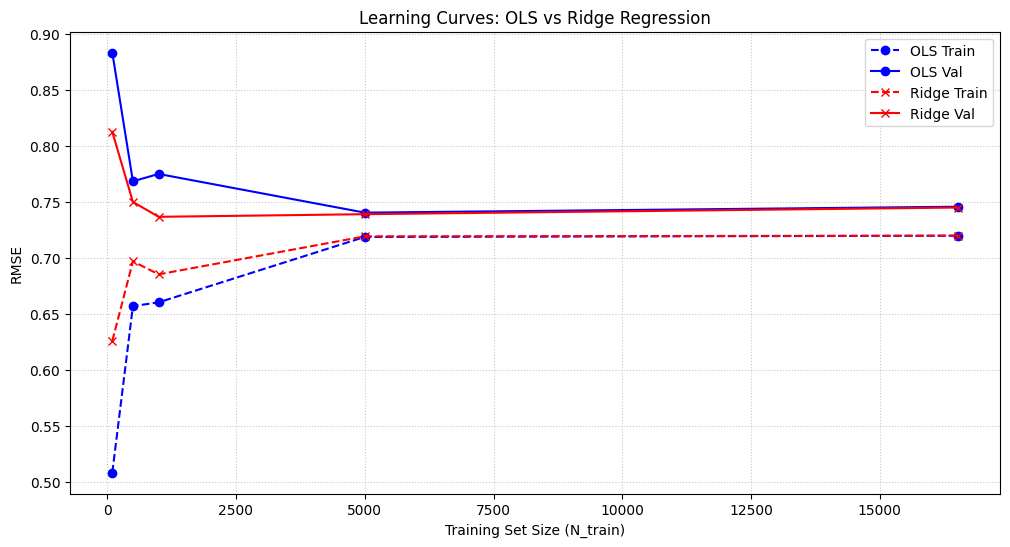

In [17]:
from sklearn.model_selection import train_test_split

# 1. Create a fixed 20% validation set
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 2. Define training sizes and lists to store RMSE
N_train_sizes = [100, 500, 1000, 5000, len(X_train_full)]
best_lambda = best_grid_lam # Using the best lambda found in 4.2.3

ols_train_rmse, ols_val_rmse = [], []
ridge_train_rmse, ridge_val_rmse = [], []

# 3. Train on increasing subsets of data
for n in N_train_sizes:
    # Subset the training data
    X_tr = X_train_full[:n]
    y_tr = y_train_full[:n]
    
    # --- OLS (Ridge with lambda = 0) ---
    ols = RidgeRegression(lambda_=0.0)
    ols.fit(X_tr, y_tr)
    ols_train_rmse.append(np.sqrt(mean_squared_error(y_tr, ols.predict(X_tr))))
    ols_val_rmse.append(np.sqrt(mean_squared_error(y_val, ols.predict(X_val))))
    
    # --- Ridge (with best lambda) ---
    ridge = RidgeRegression(lambda_=best_lambda)
    ridge.fit(X_tr, y_tr)
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_tr, ridge.predict(X_tr))))
    ridge_val_rmse.append(np.sqrt(mean_squared_error(y_val, ridge.predict(X_val))))

# 4. Plotting the Learning Curves
plt.figure(figsize=(12, 6))

# Plot OLS Curves
plt.plot(N_train_sizes, ols_train_rmse, marker='o', color='blue', linestyle='--', label='OLS Train')
plt.plot(N_train_sizes, ols_val_rmse, marker='o', color='blue', linestyle='-', label='OLS Val')

# Plot Ridge Curves
plt.plot(N_train_sizes, ridge_train_rmse, marker='x', color='red', linestyle='--', label='Ridge Train')
plt.plot(N_train_sizes, ridge_val_rmse, marker='x', color='red', linestyle='-', label='Ridge Val')

plt.xlabel('Training Set Size (N_train)')
plt.ylabel('RMSE')
plt.title('Learning Curves: OLS vs Ridge Regression')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('../figures/Learning_Curves_OLS_vs_Ridge_Regression.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from src.logistic_regression import MulticlassLogisticRegressionOvR

# 1. Load the Wine dataset
wine = load_wine()
X, y = wine.data, wine.target

# 2. Split into training and testing sets (e.g., 70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Scale the features (Crucial for gradient descent to converge smoothly)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the OvR Multiclass model
# Note: Using a smaller learning rate and L2 penalty for stability
ovr_model = MulticlassLogisticRegressionOvR(lr=0.01, lambda_=0.1, max_iter=2000)
ovr_model.fit(X_train_scaled, y_train)

# 5. Predict on the test set
y_pred = ovr_model.predict(X_test_scaled)

# 6. Evaluate and report Accuracy and Confusion Matrix
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 98.15%

Confusion Matrix:
[[19  0  0]
 [ 1 20  0]
 [ 0  0 14]]


In [19]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from src.naive_bayes import GaussianNaiveBayes

# Load Data
wine = load_wine()
X, y = wine.data, wine.target

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features (Crucial for Logistic Regression, optional but fine for NB)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 1. Train and Evaluate Gaussian Naive Bayes ---
nb_model = GaussianNaiveBayes()
nb_model.fit(X_train_scaled, y_train)
nb_preds = nb_model.predict(X_test_scaled)

print("--- Gaussian Naive Bayes ---")
print(f"Accuracy:  {accuracy_score(y_test, nb_preds):.4f}")
print(f"Precision: {precision_score(y_test, nb_preds, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, nb_preds, average='macro'):.4f}")
print(f"F1 Score:  {f1_score(y_test, nb_preds, average='macro'):.4f}\n")

# --- 2. Train and Evaluate Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("--- Logistic Regression ---")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.4f}")
print(f"Precision: {precision_score(y_test, lr_preds, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, lr_preds, average='macro'):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr_preds, average='macro'):.4f}")

--- Gaussian Naive Bayes ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

--- Logistic Regression ---
Accuracy:  0.9815
Precision: 0.9778
Recall:    0.9841
F1 Score:  0.9804


Loading data...
Extracting features...
Training models...
Evaluating models...

--- Logistic Regression ---
F1 Score: 0.9151
AUC-ROC:  0.9789

--- Gaussian Naive Bayes ---
F1 Score: 0.5692
AUC-ROC:  0.5116


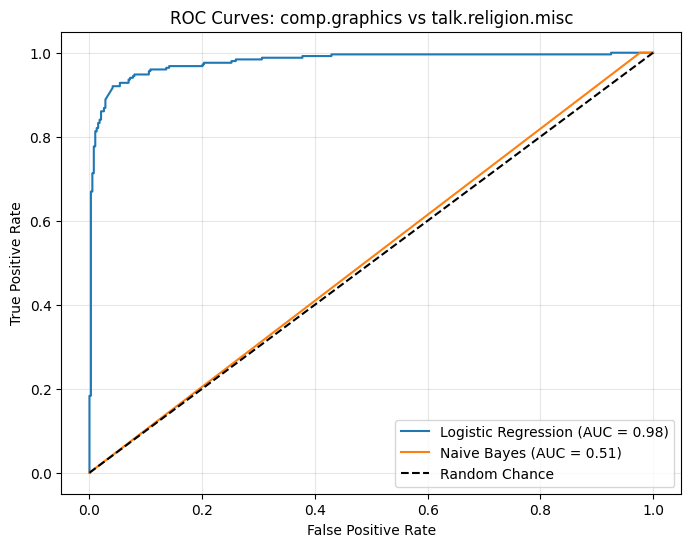

In [20]:

%load_ext autoreload
%autoreload 2

from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# --Custom Imports Go Here ---
from src.text_features import BagOfWords, TfidfTransformer
from src.logistic_regression import LogisticRegression
from src.naive_bayes import GaussianNaiveBayes
# -----------------------------------

# 1. Load the 20 Newsgroups Data
print("Loading data...")
categories = ['comp.graphics', 'talk.religion.misc']
data_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
data_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

y_train = data_train.target
y_test = data_test.target

# 2. Extract Features from Scratch
print("Extracting features...")
bow = BagOfWords(max_features=5000)
X_train_counts = bow.fit(data_train.data).transform(data_train.data)
X_test_counts = bow.transform(data_test.data)

tfidf = TfidfTransformer()
X_train_tfidf = tfidf.fit(X_train_counts).transform(X_train_counts)
X_test_tfidf = tfidf.transform(X_test_counts)

# 3. Train Models
print("Training models...")
# Using the models imported from your src folder
lr_model = LogisticRegression(lr=0.1, lambda_=0.1, max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

nb_model = GaussianNaiveBayes()
nb_model.fit(X_train_tfidf, y_train)

# 4. Predict and Evaluate
print("Evaluating models...")
# Logistic Regression Outputs
lr_probs = lr_model.predict_proba(X_test_tfidf)
lr_preds = lr_model.predict(X_test_tfidf)

# Naive Bayes Outputs
nb_probs = nb_model.predict_proba(X_test_tfidf)[:, 1] 
nb_preds = nb_model.predict(X_test_tfidf)

# Metrics
print("\n--- Logistic Regression ---")
print(f"F1 Score: {f1_score(y_test, lr_preds):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, lr_probs):.4f}")

print("\n--- Gaussian Naive Bayes ---")
print(f"F1 Score: {f1_score(y_test, nb_preds):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, nb_probs):.4f}")

# 5. Plot ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.2f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_score(y_test, nb_probs):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

plt.title('ROC Curves: comp.graphics vs talk.religion.misc')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('../figures/ROC_Curves_comp_graphics_vs_talk_religion_misc.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()